In [1]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import networkx as nx
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries, get_relevant_output_layers
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [25]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'baby1'
    date: str = '220226to527' # '250313' #  #  # # "230204"#'240816to26'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'
    folder_name = 'fewer_occlusion'

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

(1024, 4379)


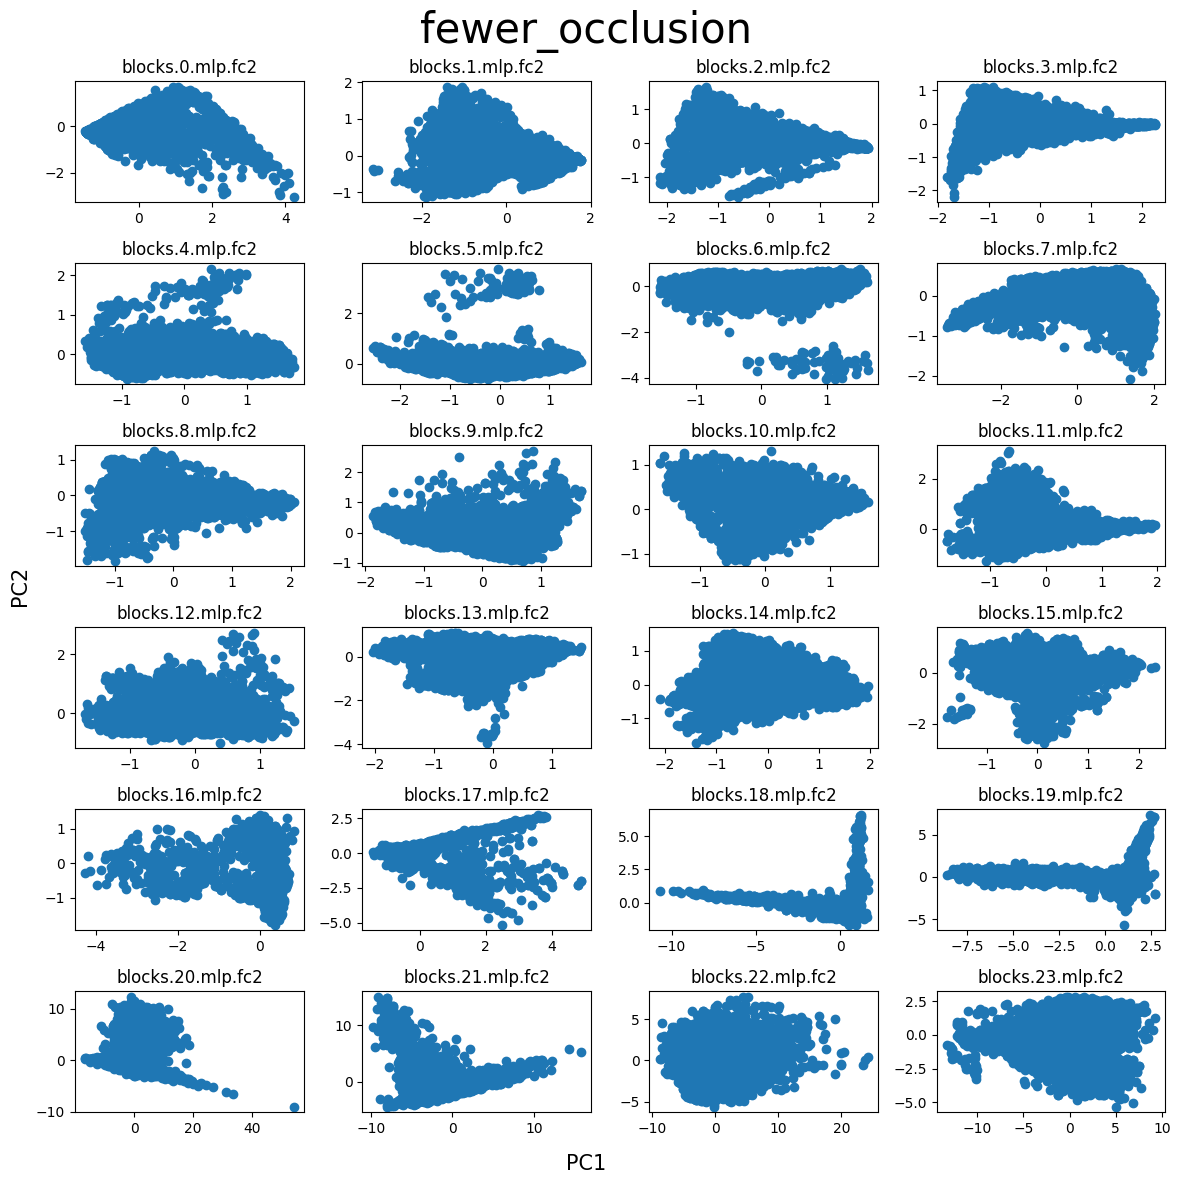

In [26]:
fig, ax = plt.subplots(6, 4, figsize=(12, 12))
ax = ax.flatten()
for i, l in enumerate(layers):
    feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{l}_features_{cfg.pooling}pool.npz"
    feats = np.load(feats_filename)["arr_0"]
    pca = PCA(n_components=2)
    f_pca = pca.fit_transform(feats.T)
    ax[i].scatter(f_pca[:,0], f_pca[:,1])
    ax[i].set_title(l)
print(feats.shape)
fig.supylabel("PC2", fontsize=15)
fig.supxlabel("PC1", fontsize=15)
fig.suptitle(cfg.folder_name, fontsize=30)
fig.tight_layout()

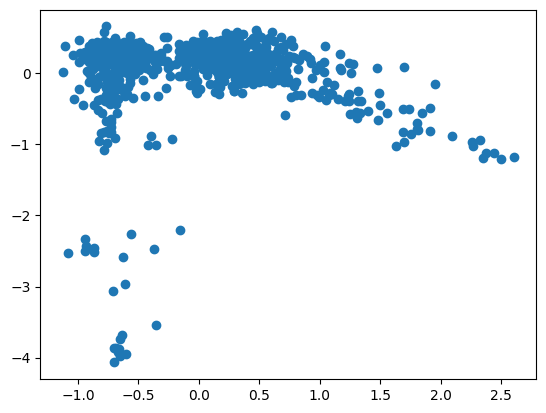